# Figure 1a – Radial profiles of full side-chain maps (uniform B-factors)

Reads `data/processed/figure_1a.csv` and saves `figures/figure_1a.pdf`.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# ── resolve project root ────────────────────────────────────────────────────
cwd = Path.cwd()
ROOT_DIR = cwd.parent if cwd.name == 'notebooks' else cwd
sys.path.insert(0, str(ROOT_DIR / 'notebooks'))

from plot_utils import setup_style, pretty_plot_radial_profile

PROCESSED = ROOT_DIR / 'data' / 'processed'
FIGURES   = ROOT_DIR / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

setup_style(font_scale=2.0)


In [2]:
df = pd.read_csv(PROCESSED / 'figure_1a.csv')
freq = df['freq'].values
bfactor_cols = [c for c in df.columns if c.startswith('bfactor_')]
bfactors     = [int(c.split('_')[1]) for c in bfactor_cols]
profiles     = [df[c].values for c in bfactor_cols]


Saved figures/figure_1a.png


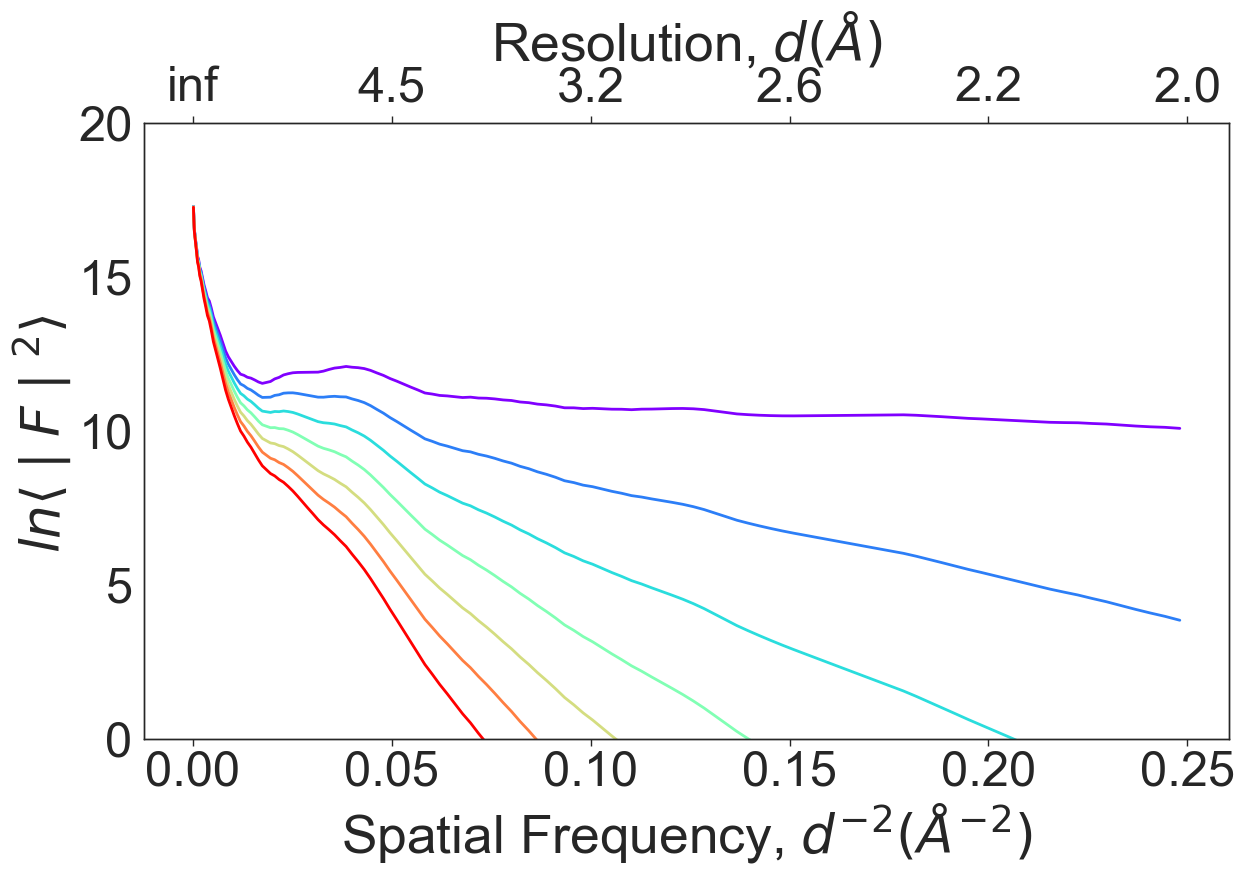

In [3]:
fig = pretty_plot_radial_profile(
        freq, 
        profiles, 
        showlegend=False, 
        normalise=False, 
        squared_amplitudes=True, 
        logScale=True, 
        ylims=[0,20],
        crop_freq=[100,2], 
        linewidth=2, 
        fontscale=4
    )
fig.savefig(FIGURES / 'figure_1a.png', dpi=300, bbox_inches='tight', format='png')
print('Saved figures/figure_1a.png')
